In [1]:
import pandas as pd
import lightgbm as lgb
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

/home/rigonzal/miniconda3/envs/genv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib
matplotlib.__version__

'3.8.4'

In [3]:
shap.__version__

'0.46.0'

# 0.Config

In [4]:
path_fe = "../../outputs/fe/"

# 1. Data

In [6]:
df_mdt = pd.read_parquet(f"{path_fe}all_joined_fe_delta_years=4.parquet")
df_mdt.shape

(2346727, 87)

# 2. Processing

In [7]:
# Create binary target
df_mdt["target"] = (df_mdt["arrdelay"] >= 15).astype(int)
df_mdt = df_mdt.drop(["arrdelay"], axis=1)
df_mdt["target"].mean()

np.float64(0.2199407941358326)

In [8]:
# 🔹 Define features and target
X = df_mdt.drop(columns=["unique_key", "month","target"])
y = df_mdt["target"]

In [9]:
# 🔹 Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train

,day,crsdeptime,avg_delay_route_last_30d,avg_delay_airline_dest_last_14d,rank,air_safety__general_aviation_fatalities,us_airline_traffic__total__seasonally_adjusted,us_airline_traffic__international__seasonally_adjusted,us_airline_traffic__domestic__seasonally_adjusted,state_and_local_government_construction_spending__conservation_and_development,...,operating_airline_B6,operating_airline_DL,operating_airline_EV,operating_airline_PT,operating_airline_UA,operating_airline_VX,operating_airline_YX,aircraft_service_attendants_and_transportation_workers_all_other,originstate_ID,deststate_ID
1766310,13,1330,-3.935733,3.503876,29.0,26.0,30200000.0,2840000.0,27360000.0,290000000.0,...,1,0,0.0,0.0,0,NaN,0,33430.0,NaN,NaN
2108168,15,1837,8.286195,6.748603,22.0,51.0,64690000.0,5690000.0,59000000.0,304000000.0,...,0,0,NaN,NaN,0,NaN,0,NaN,0.0,0.0
54610,22,1045,21.331878,16.151076,22.0,31.0,75060000.0,9420000.0,65640000.0,364000000.0,...,0,0,0.0,0.0,1,0.0,0,NaN,NaN,NaN
79487,17,1540,-2.409556,-3.082569,26.0,29.0,74020000.0,9230000.0,64800000.0,383000000.0,...,0,1,0.0,0.0,0,0.0,0,NaN,NaN,NaN
1161479,14,1649,12.711688,-1.200000,28.0,48.0,75930000.0,9540000.0,66390000.0,266000000.0,...,0,0,0.0,0.0,0,NaN,0,34940.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732180,15,1500,-3.626186,4.553663,10.0,32.0,77170000.0,9610000.0,67570000.0,232000000.0,...,0,0,0.0,0.0,0,NaN,0,34940.0,NaN,NaN
110268,24,1045,-2.222222,-21.250000,26.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0.0,0.0,0,0.0,0,NaN,NaN,NaN
1692743,20,1516,-10.808333,-11.547619,5.0,21.0,7560000.0,180000.0,7370000.0,276000000.0,...,0,1,0.0,0.0,0,NaN,0,33430.0,NaN,NaN
2229084,10,1600,-6.268695,-12.408451,28.0,38.0,64190000.0,5970000.0,58220000.0,300000000.0,...,0,0,NaN,NaN,0,NaN,0,NaN,0.0,0.0


# 3. Train

In [11]:

# 🔹 Train LightGBM Model
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "random_state": 42
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

model = lgb.train(params, train_data, valid_sets=[val_data], num_boost_round=50,)

# 4. Metrics

In [12]:
# 🔹 Predictions & Metrics
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# Convert probabilities to binary (threshold = 0.5)
y_train_pred_bin = (y_train_pred >= 0.5).astype(int)
y_val_pred_bin = (y_val_pred >= 0.5).astype(int)

# 🔹 Compute Metrics
train_auc = roc_auc_score(y_train, y_train_pred)
val_auc = roc_auc_score(y_val, y_val_pred)

train_acc = accuracy_score(y_train, y_train_pred_bin)
val_acc = accuracy_score(y_val, y_val_pred_bin)

print(f"🔹 Train AUC: {train_auc:.3f} | Train Accuracy: {train_acc:.3f}")
print(f"🔹 Val AUC: {val_auc:.3f} | Val Accuracy: {val_acc:.3f}")
print("\n🔹 Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_bin))

🔹 Train AUC: 0.738 | Train Accuracy: 0.794
🔹 Val AUC: 0.736 | Val Accuracy: 0.793

🔹 Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.80      0.98      0.88    365648
           1       0.68      0.12      0.20    103698

    accuracy                           0.79    469346
   macro avg       0.74      0.55      0.54    469346
weighted avg       0.77      0.79      0.73    469346



# Feature importance SHAPs analysis

In [13]:
explainer = shap.Explainer(model)
shap_values = explainer(X_val)

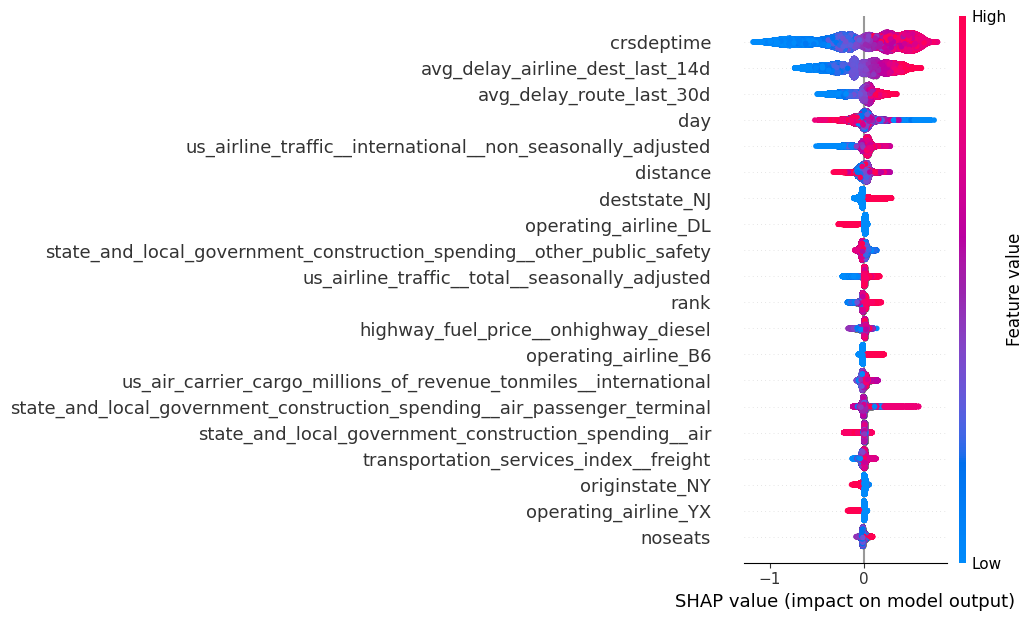

In [14]:
# 🔹 SHAP Summary Plot
#plt.figure(figsize=(18, 6))
fig = shap.summary_plot(shap_values, X_val, show=False)
w, h = plt.gcf().get_size_inches()
plt.gcf().set_size_inches(w*7, w*0.75)
plt.show()

#print(f'Original size: {plt.gcf().get_size_inches()}')
#w, _ = plt.gcf().get_size_inches()
#plt.gcf().set_size_inches(w, w*3/4)
#plt.tight_layout()
#print(f'New size: {plt.gcf().get_size_inches()}')


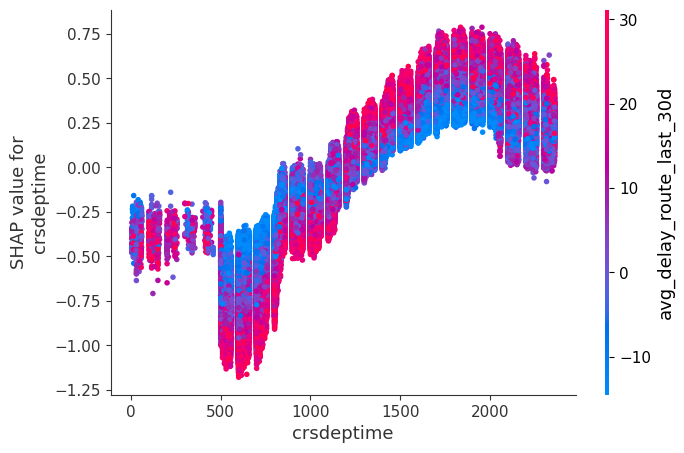

In [15]:
# 🔹 SHAP Dependence Plot for Top Feature
top_feature = X_val.columns[np.argmax(np.abs(shap_values.values).mean(axis=0))]
shap.dependence_plot(top_feature, shap_values.values, X_val)

plt.show()